In [ ]:
import os
import re
import json
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet34, ResNet34_Weights

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------
METADATA_PATH = "/content/new_metadata.xlsx"
IMAGES_DIR    = "/content/drive/MyDrive/Colab_Notebooks/For_Training/Cropped"  # folder containing all Croppedmicrograph*.png
OUTPUT_DIR    = "/content/drive/MyDrive/Colab_Notebooks/model_output"  # where checkpoints/results get saved
# ---------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel(METADATA_PATH)
print("Rows in metadata file:", len(df))


df["micrograph_id"] = df["path"].str.extract(r"(\d+)").astype(int)


df["filename"] = df["micrograph_id"].apply(lambda n: f"Croppedmicrograph{n}.png")


df["filepath"] = df["filename"].apply(lambda f: os.path.join(IMAGES_DIR, f))
exists_mask = df["filepath"].apply(os.path.isfile)

print(f"Matched image+metadata pairs: {exists_mask.sum()} / {len(df)}")
if exists_mask.sum() < len(df):
    missing = df.loc[~exists_mask, "filename"].tolist()
    print(f"  {len(missing)} metadata rows had no matching file, e.g.: {missing[:10]}")

df = df.loc[exists_mask].reset_index(drop=True)


df = df.dropna(subset=["primary_microconstituent"]).reset_index(drop=True)
print("Final usable rows:", len(df))
df.head()

Rows in metadata file: 598
Matched image+metadata pairs: 598 / 598
Final usable rows: 598


,path,anneal_temperature,anneal_time,anneal_time_unit,cool_method,magnification,primary_microconstituent,micrograph_id,filename,filepath
0,micrograph2.png,800,85,H,Q,1964X,spheroidite,2,Croppedmicrograph2.png,/content/drive/MyDrive/Colab_Notebooks/For_Tra...
1,micrograph4.png,970,90,M,FC,NaN,pearlite+spheroidite,4,Croppedmicrograph4.png,/content/drive/MyDrive/Colab_Notebooks/For_Tra...
2,micrograph5.png,750,5,M,Q,4910X,pearlite,5,Croppedmicrograph5.png,/content/drive/MyDrive/Colab_Notebooks/For_Tra...
3,micrograph6.png,970,90,M,AR,1178X,spheroidite,6,Croppedmicrograph6.png,/content/drive/MyDrive/Colab_Notebooks/For_Tra...
4,micrograph7.png,970,90,M,Q,982x,spheroidite+widmanstatten,7,Croppedmicrograph7.png,/content/drive/MyDrive/Colab_Notebooks/For_Tra...


primary_microconstituent
spheroidite                  372
network                      101
spheroidite+widmanstatten     77
pearlite+spheroidite          28
pearlite                      15
pearlite+widmanstatten         5
Name: count, dtype: int64


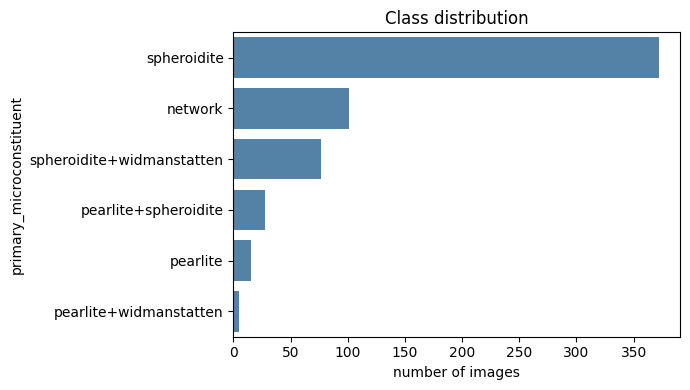

In [ ]:
counts = df["primary_microconstituent"].value_counts()
print(counts)

plt.figure(figsize=(7, 4))
sns.barplot(x=counts.values, y=counts.index, color="steelblue")
plt.xlabel("number of images")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

In [ ]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["primary_microconstituent"])
NUM_CLASSES = len(le.classes_)
print("Classes:", list(le.classes_))

def safe_stratified_split(frame, test_size, label_col="label"):
    try:
        return train_test_split(
            frame, test_size=test_size, stratify=frame[label_col], random_state=SEED
        )
    except ValueError as e:
        print("Warning: falling back to a non-stratified split ->", e)
        return train_test_split(frame, test_size=test_size, random_state=SEED)

train_df, temp_df = safe_stratified_split(df, test_size=0.30)
val_df, test_df = safe_stratified_split(temp_df, test_size=0.50)

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print("\nPer-split class counts:")
split_counts = pd.DataFrame({
    "train": train_df["primary_microconstituent"].value_counts(),
    "val":   val_df["primary_microconstituent"].value_counts(),
    "test":  test_df["primary_microconstituent"].value_counts(),
}).fillna(0).astype(int)
print(split_counts)

Classes: ['network', 'pearlite', 'pearlite+spheroidite', 'pearlite+widmanstatten', 'spheroidite', 'spheroidite+widmanstatten']
train: 418  val: 90  test: 90

Per-split class counts:
                           train  val  test
primary_microconstituent                   
spheroidite                  260   56    56
network                       71   15    15
spheroidite+widmanstatten     54   12    11
pearlite+spheroidite          20    4     4
pearlite                      10    2     3
pearlite+widmanstatten         3    1     1


In [ ]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MicrostructureDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        image = self.transform(image)
        label = int(row["label"])
        return image, label


BATCH_SIZE = 16

train_ds = MicrostructureDataset(train_df, train_transform)
val_ds   = MicrostructureDataset(val_df, eval_transform)
test_ds  = MicrostructureDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    param.requires_grad = name.startswith("layer4") or name.startswith("fc")

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 183MB/s]


Trainable params: 13,117,446 / 21,287,750


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(le.classes_, class_weights.cpu().numpy().round(2))))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

Class weights: {'network': np.float32(0.98), 'pearlite': np.float32(6.97), 'pearlite+spheroidite': np.float32(3.48), 'pearlite+widmanstatten': np.float32(23.22), 'spheroidite': np.float32(0.27), 'spheroidite+widmanstatten': np.float32(1.29)}


In [ ]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if train_mode:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, acc, macro_f1


NUM_EPOCHS = 30
PATIENCE = 8
best_val_f1 = -1.0
best_state = None
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, _ = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"epoch {epoch:02d} | train loss {train_loss:.3f} acc {train_acc:.3f} "
          f"| val loss {val_loss:.3f} acc {val_acc:.3f} macro-F1 {val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"No improvement for {PATIENCE} epochs, stopping early.")
            break

model.load_state_dict(best_state)
print(f"\nBest validation macro-F1: {best_val_f1:.3f}")

epoch 01 | train loss 1.358 acc 0.361 | val loss 1.263 acc 0.578 macro-F1 0.462
epoch 02 | train loss 0.746 acc 0.754 | val loss 0.541 acc 0.811 macro-F1 0.689
epoch 03 | train loss 0.420 acc 0.804 | val loss 0.562 acc 0.833 macro-F1 0.653
epoch 04 | train loss 0.398 acc 0.859 | val loss 0.393 acc 0.856 macro-F1 0.840
epoch 05 | train loss 0.384 acc 0.883 | val loss 0.359 acc 0.811 macro-F1 0.746
epoch 06 | train loss 0.262 acc 0.902 | val loss 0.382 acc 0.867 macro-F1 0.847
epoch 07 | train loss 0.244 acc 0.904 | val loss 0.337 acc 0.878 macro-F1 0.893
epoch 08 | train loss 0.273 acc 0.897 | val loss 0.451 acc 0.900 macro-F1 0.912
epoch 09 | train loss 0.207 acc 0.900 | val loss 0.422 acc 0.900 macro-F1 0.841
epoch 10 | train loss 0.265 acc 0.897 | val loss 0.362 acc 0.867 macro-F1 0.821
epoch 11 | train loss 0.170 acc 0.911 | val loss 0.308 acc 0.911 macro-F1 0.798
epoch 12 | train loss 0.200 acc 0.923 | val loss 0.405 acc 0.856 macro-F1 0.832
epoch 13 | train loss 0.211 acc 0.921 | 

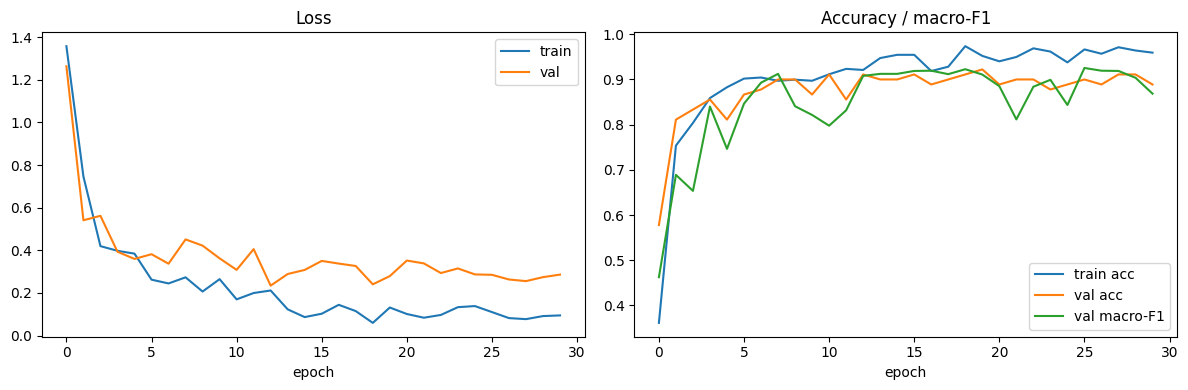

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train acc")
axes[1].plot(history["val_acc"], label="val acc")
axes[1].plot(history["val_f1"], label="val macro-F1")
axes[1].set_title("Accuracy / macro-F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

Test accuracy: 0.911   Test macro-F1: 0.892

                           precision    recall  f1-score   support

                  network       1.00      1.00      1.00        15
                 pearlite       0.60      1.00      0.75         3
     pearlite+spheroidite       1.00      1.00      1.00         4
   pearlite+widmanstatten       1.00      1.00      1.00         1
              spheroidite       0.95      0.93      0.94        56
spheroidite+widmanstatten       0.70      0.64      0.67        11

                 accuracy                           0.91        90
                macro avg       0.87      0.93      0.89        90
             weighted avg       0.92      0.91      0.91        90



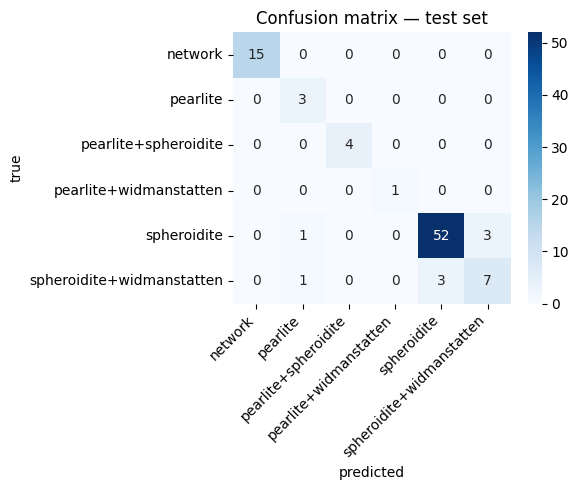

In [ ]:
test_loss, test_acc, test_f1 = run_epoch(test_loader, train_mode=False)
print(f"Test accuracy: {test_acc:.3f}   Test macro-F1: {test_f1:.3f}\n")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels, all_preds, target_names=le.classes_, zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("predicted")
plt.ylabel("true")
plt.xticks(rotation=45, ha="right")
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

In [ ]:
checkpoint_path = os.path.join(OUTPUT_DIR, "microconstituent_resnet34.pth")
torch.save(model.state_dict(), checkpoint_path)

label_map_path = os.path.join(OUTPUT_DIR, "label_classes.json")
with open(label_map_path, "w") as f:
    json.dump(list(le.classes_), f)

print("Saved model to:", checkpoint_path)
print("Saved label mapping to:", label_map_path)

Saved model to: /content/drive/MyDrive/Colab_Notebooks/model_output/microconstituent_resnet34.pth
Saved label mapping to: /content/drive/MyDrive/Colab_Notebooks/model_output/label_classes.json


In [ ]:
import json
import torch
import torch.nn as nn
from torchvision.models import resnet34

try:
    import onnx
except ImportError:
    print("Installing onnx package...")
    !pip install onnx
    import onnx


CHECKPOINT_PATH = "/content/drive/MyDrive/Colab_Notebooks/model_output/microconstituent_resnet34.pth"
LABELS_PATH      = "/content/drive/MyDrive/Colab_Notebooks/model_output/label_classes.json"
ONNX_OUT_PATH    = "/content/drive/MyDrive/Colab_Notebooks/model_output/microconstituent_resnet34.onnx"

with open(LABELS_PATH) as f:
    class_names = json.load(f)

model = resnet34(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location="cpu"))
model.eval()

dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model,
    dummy_input,
    ONNX_OUT_PATH,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=12,
    dynamo=False,
)

onnx_model = onnx.load(ONNX_OUT_PATH, load_external_data=True)
onnx.save_model(onnx_model, ONNX_OUT_PATH, save_as_external_data=False)

import os

data_file = ONNX_OUT_PATH + ".data"
if os.path.exists(data_file):
    os.remove(data_file)

size_mb = os.path.getsize(ONNX_OUT_PATH) / 1e6
print(f"Saved single-file ONNX model to: {ONNX_OUT_PATH} ({size_mb:.1f} MB)")

/tmp/ipykernel_2259/841590320.py:28: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Saved single-file ONNX model to: /content/drive/MyDrive/Colab_Notebooks/model_output/microconstituent_resnet34.onnx (85.1 MB)
